**Anime Dataset Analysis**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df = pd.read_csv('anime.csv')

In [4]:
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [6]:
df.columns

Index(['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members'], dtype='str')

In [65]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  str    
 2   genre     12232 non-null  str    
 3   type      12269 non-null  str    
 4   episodes  12294 non-null  str    
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), str(4)
memory usage: 672.5 KB


In [66]:
df.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


In [10]:
df.dtypes

anime_id      int64
name            str
genre           str
type            str
episodes        str
rating      float64
members       int64
dtype: object

In [22]:
df.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

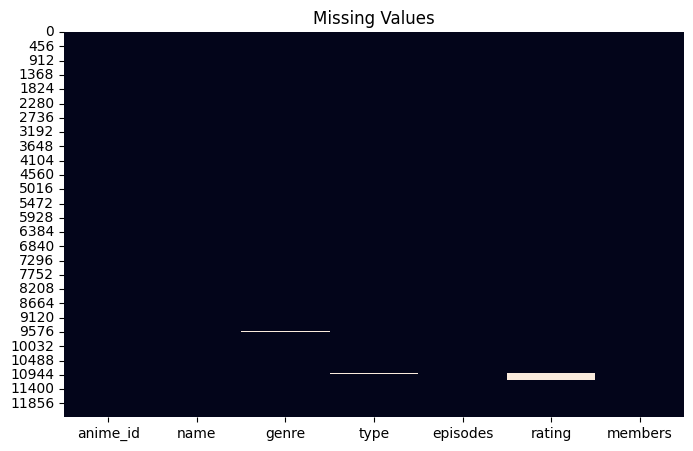

In [67]:
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

The dataset contains missing values mainly in the rating column. Before performing analysis, it is important to identify and account for these missing values to avoid misleading conclusions.

**Finding Most Popular Animes (By Top Members And Top Rating)**

In [23]:
df.columns

Index(['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members'], dtype='str')

In [30]:
df.nlargest(10, 'members')[['name','genre','members', 'rating']]

,name,genre,members,rating
40,Death Note,"Mystery, Police, Psychological, Supernatural, ...",1013917,8.71
86,Shingeki no Kyojin,"Action, Drama, Fantasy, Shounen, Super Power",896229,8.54
804,Sword Art Online,"Action, Adventure, Fantasy, Game, Romance",893100,7.83
1,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",793665,9.26
159,Angel Beats!,"Action, Comedy, Drama, School, Supernatural",717796,8.39
19,Code Geass: Hangyaku no Lelouch,"Action, Mecha, Military, School, Sci-Fi, Super...",715151,8.83
841,Naruto,"Action, Comedy, Martial Arts, Shounen, Super P...",683297,7.81
3,Steins;Gate,"Sci-Fi, Thriller",673572,9.17
445,Mirai Nikki (TV),"Action, Mystery, Psychological, Shounen, Super...",657190,8.07
131,Toradora!,"Comedy, Romance, School, Slice of Life",633817,8.45


Judging solely by number of members who votes for a particular anime, the most popular ones are : Deathnote, Attack On titan, Sword Art Online, Fullmetal Alchemist : Brotherhood and Angel Beats! While these have solid ratings too (all>7.5), this may show the strength of fandom of an anime more than the actual quality. But also, as number of members increase, it is difficult to mentain a high rating. Therefore, this may be a good measure of popularity.

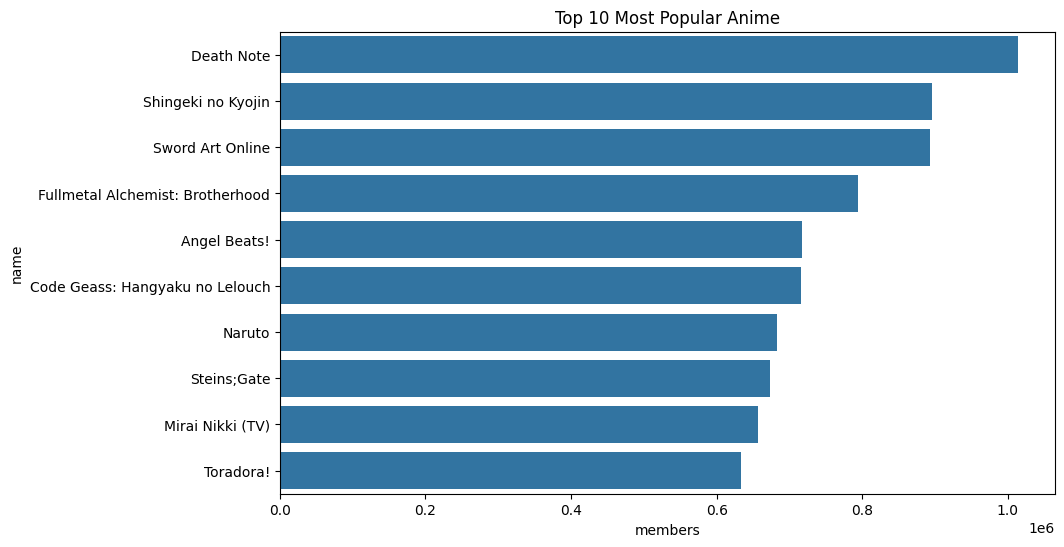

In [68]:
top_members = df.nlargest(10,'members')

plt.figure(figsize=(10,6))
sns.barplot(
    x='members',
    y='name',
    data=top_members
)

plt.title("Top 10 Most Popular Anime")
plt.show()

Death Note and Attack on Titan have some of the largest audience sizes, indicating strong mainstream appeal.

In [29]:
df.nlargest(10, 'rating')[['name', 'genre', 'rating', 'members']]

,name,genre,rating,members
10464,Taka no Tsume 8: Yoshida-kun no X-Files,"Comedy, Parody",10.00,13
10400,Spoon-hime no Swing Kitchen,"Adventure, Kids",9.60,47
9595,Mogura no Motoro,Slice of Life,9.50,62
0,Kimi no Na wa.,"Drama, Romance, School, Supernatural",9.37,200630
9078,Kahei no Umi,Historical,9.33,44
1,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",9.26,793665
2,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",9.25,114262
10786,Yakusoku: Africa Mizu to Midori,"Drama, Kids",9.25,53
3,Steins;Gate,"Sci-Fi, Thriller",9.17,673572
4,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",9.16,151266


Now, in contrast, judging by rating, more niche animes (with members below 62 in top 3) have high ratings with 'Taka no Tsume 8: Yoshida-kun no X-Files' bragging a perfect 10, though it is voted by only 13 members. As the number of members is low, it is easy to mentain perfect ratings, therefore this may not be a good measure of popularity.

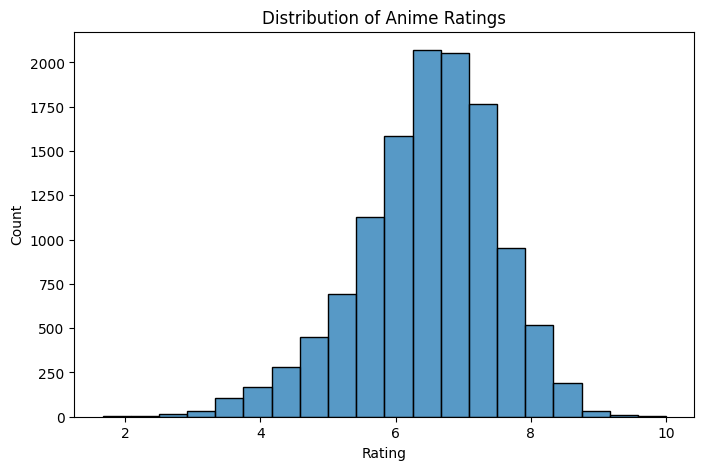

In [69]:
plt.figure(figsize=(8,5))
sns.histplot(df['rating'], bins=20)

plt.title("Distribution of Anime Ratings")
plt.xlabel("Rating")
plt.show()

Most anime ratings are concentrated between 6 and 8, suggesting that extremely low and extremely high ratings are relatively uncommon.

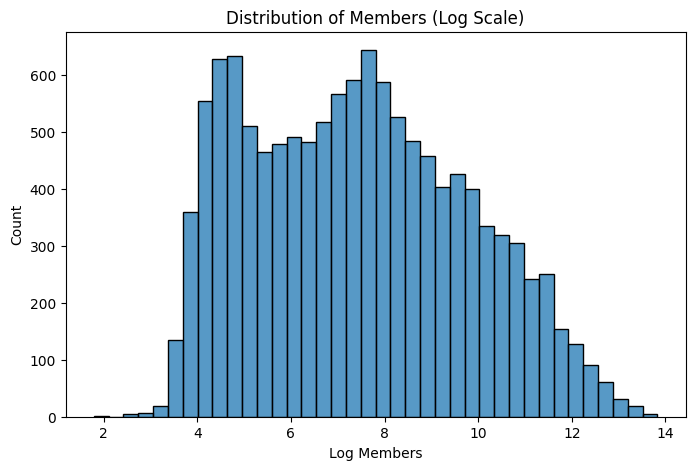

In [70]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df['members']))

plt.title("Distribution of Members (Log Scale)")
plt.xlabel("Log Members")
plt.show()

The distribution is highly right-skewed. A small number of anime attract very large audiences while most anime have comparatively fewer members.

Now lets apply a threshold of minimum members = 1000 and then filter by rating, combining strengths of both parameters

In [31]:
df[df['members']>=1000].nlargest(10,'rating')[['name', 'genre', 'rating', 'members']]

,name,genre,rating,members
0,Kimi no Na wa.,"Drama, Romance, School, Supernatural",9.37,200630
1,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",9.26,793665
2,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",9.25,114262
3,Steins;Gate,"Sci-Fi, Thriller",9.17,673572
4,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",9.16,151266
5,Haikyuu!!: Karasuno Koukou VS Shiratorizawa Ga...,"Comedy, Drama, School, Shounen, Sports",9.15,93351
6,Hunter x Hunter (2011),"Action, Adventure, Shounen, Super Power",9.13,425855
7,Ginga Eiyuu Densetsu,"Drama, Military, Sci-Fi, Space",9.11,80679
9,Gintama&#039;: Enchousen,"Action, Comedy, Historical, Parody, Samurai, S...",9.11,81109
8,Gintama Movie: Kanketsu-hen - Yorozuya yo Eien...,"Action, Comedy, Historical, Parody, Samurai, S...",9.10,72534


Now we obtain a more meaningful list. Applying a minimum member threshold removes niche titles with very few votes. This produces rankings that better reflect both popularity and audience satisfaction. Kimi no Na wa leads the resule with 200630 members' votes and a rating of 9.37, followed by Fullmetal Alchemist: Brotherhood and Gintama.

In [35]:
df[df['members']>=100000].nlargest(10,'rating')[['name', 'genre', 'rating', 'members']]

,name,genre,rating,members
0,Kimi no Na wa.,"Drama, Romance, School, Supernatural",9.37,200630
1,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",9.26,793665
2,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",9.25,114262
3,Steins;Gate,"Sci-Fi, Thriller",9.17,673572
4,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",9.16,151266
6,Hunter x Hunter (2011),"Action, Adventure, Shounen, Super Power",9.13,425855
10,Clannad: After Story,"Drama, Fantasy, Romance, Slice of Life, Supern...",9.06,456749
11,Koe no Katachi,"Drama, School, Shounen",9.05,102733
12,Gintama,"Action, Comedy, Historical, Parody, Samurai, S...",9.04,336376
13,Code Geass: Hangyaku no Lelouch R2,"Action, Drama, Mecha, Military, Sci-Fi, Super ...",8.98,572888


Even after increasing threshold to 100000 members, the results remained same, showing the popularity of these animes!

**Type Breakdown**

In [37]:
df['type'].value_counts()

type
TV         3787
OVA        3311
Movie      2348
Special    1676
ONA         659
Music       488
Name: count, dtype: int64

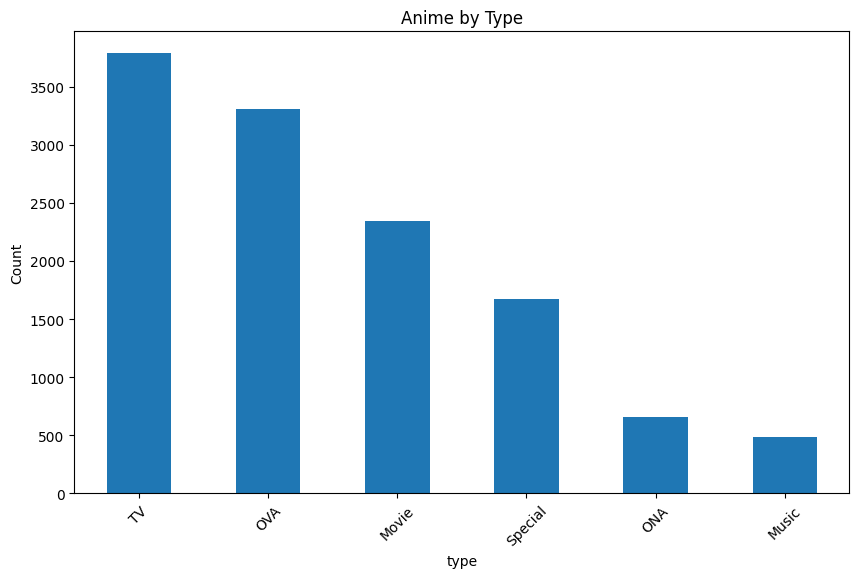

In [41]:
plt.figure(figsize=(10, 6))
df['type'].value_counts().plot(kind='bar')
plt.title('Anime by Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [40]:
df.groupby('type')['rating'].mean().sort_values(ascending = False)

type
TV         6.902299
Special    6.523501
OVA        6.375221
Movie      6.318058
ONA        5.643298
Music      5.588996
Name: rating, dtype: float64

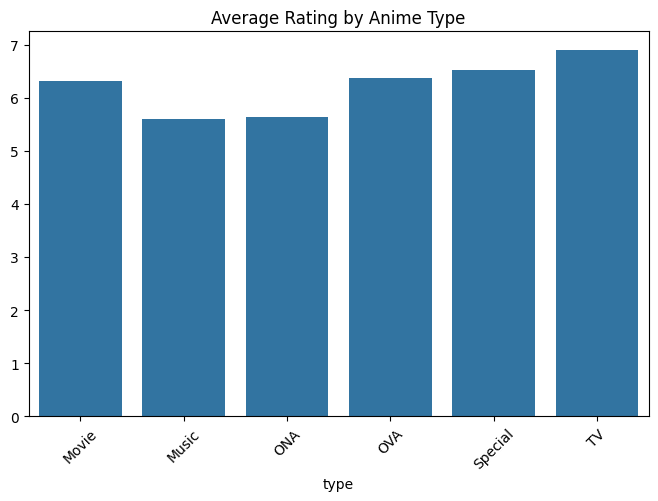

In [72]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=df.groupby('type')['rating'].mean().index,
    y=df.groupby('type')['rating'].mean().values
)

plt.title("Average Rating by Anime Type")
plt.xticks(rotation=45)
plt.show()

TV anime have the highest average ratings in this dataset. One possible explanation is that longer series allow greater character development, although additional analysis would be needed to confirm this.

One aspect worth mentioning is that OVAs and specials rank better than movies, even though movies are high budget. This is quite interesting and may be worth a thought.

**Genre Analysis**

In [44]:
df['genre'].value_counts()

genre
Hentai                                                  823
Comedy                                                  523
Music                                                   301
Kids                                                    199
Comedy, Slice of Life                                   179
                                                       ... 
Action, Comedy, Demons, Hentai, Martial Arts, School      1
Action, Comedy, Hentai, Romance, Supernatural             1
Hentai, Sports                                            1
Drama, Romance, School, Yuri                              1
Hentai, Slice of Life                                     1
Name: count, Length: 3264, dtype: int64

In [50]:
genre_split = df['genre'].str.split(', ', expand=True).stack().reset_index(drop=True)

In [52]:
genre_split.value_counts().head(20)

Comedy           4645
Action           2845
Adventure        2348
Fantasy          2309
Sci-Fi           2070
Drama            2016
Shounen          1712
Kids             1609
Romance          1464
School           1220
Slice of Life    1220
Hentai           1141
Supernatural     1037
Mecha             944
Music             860
Historical        806
Magic             778
Ecchi             637
Shoujo            603
Seinen            547
Name: count, dtype: int64

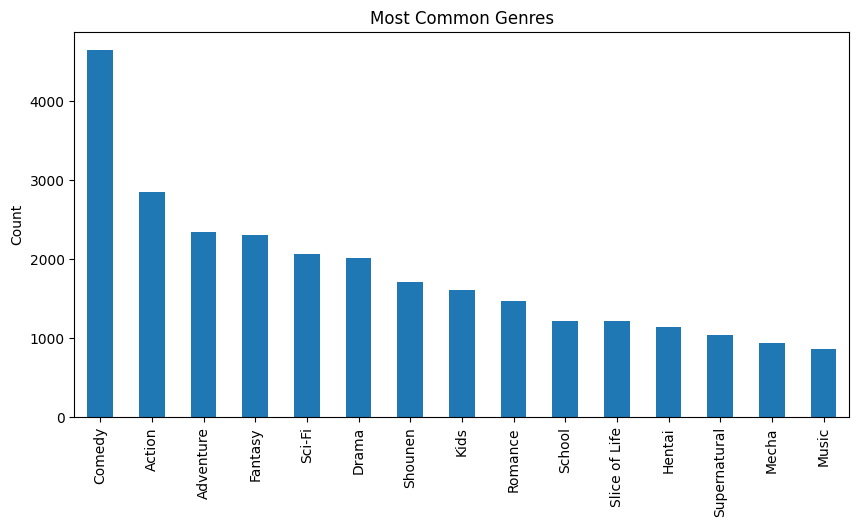

In [73]:
genre_split.value_counts().head(15).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Most Common Genres")
plt.ylabel("Count")
plt.show()

Comedy, Action and Adventure are the most common genres. 

In [53]:
genre_df = df['genre'].str.split(', ', expand=True).stack().reset_index(level=1, drop=True).to_frame()

In [54]:
genre_df.columns = ['genre']

In [55]:
genre_df = genre_df.join(df[['rating', 'members']])

In [56]:
genre_df.groupby('genre')['rating'].mean().sort_values(ascending=False).head(20)

genre
Josei            7.443077
Thriller         7.382326
Mystery          7.232412
Police           7.122051
Shounen          7.057553
Psychological    7.010398
Military         7.004904
Supernatural     7.000380
Romance          6.999054
Shoujo Ai        6.978148
Drama            6.977218
School           6.972049
Seinen           6.966353
Harem            6.965687
Shounen Ai       6.961613
Super Power      6.906785
Vampire          6.884600
Shoujo           6.875976
Samurai          6.853836
Martial Arts     6.819356
Name: rating, dtype: float64

In [59]:
fd = genre_df.groupby('genre').agg(
    mean_rating=('rating', 'mean'),
    count=('rating', 'count')
).sort_values('mean_rating', ascending=False).head(20)

In [60]:
fd

,mean_rating,count
genre,,
Josei,7.443077,52
Thriller,7.382326,86
Mystery,7.232412,485
Police,7.122051,195
Shounen,7.057553,1684
Psychological,7.010398,226
Military,7.004904,416
Supernatural,7.000380,1001
Romance,6.999054,1437


As we can see, Josei genre has the greatest mean rating (7.44) but less count : 52. Lets run a threshold of minimum 100 animes and check which genre has greatest average rating.

Thriller and Mystery rating high (7.38 and 7.23) suggests that critically engaging, plot-driven anime tend to score better than action-heavy ones

In [77]:
fd[fd['count']>=1000].nlargest(20,'mean_rating')

,mean_rating,count
genre,,
Shounen,7.057553,1684
Supernatural,7.000380,1001
Romance,6.999054,1437
Drama,6.977218,1977
School,6.972049,1176


Most popular genres according to ratings are Shounen, Supernatural, Romance, Drama and School.

**Relationship Between Popularity and Rating**

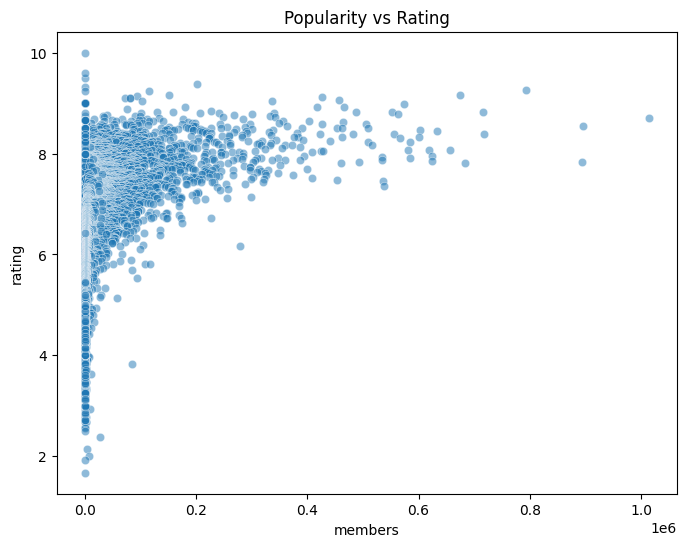

In [78]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='members',
    y='rating',
    data=df,
    alpha=0.5
)

plt.title("Popularity vs Rating")
plt.show()

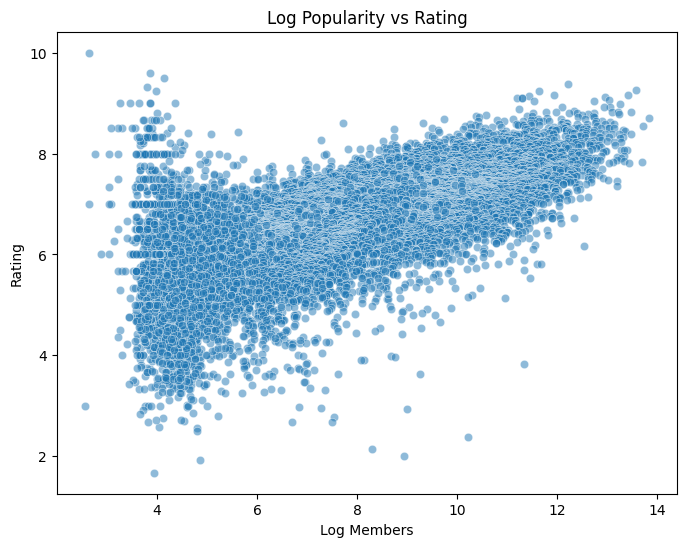

In [92]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=np.log1p(df['members']),
    y=df['rating'],
    alpha=0.5
)

plt.title("Log Popularity vs Rating")
plt.xlabel("Log Members")
plt.ylabel("Rating")

plt.show()

While some highly popular anime achieve strong ratings, popularity alone does not guarantee a high score. The relationship appears positive but relatively weak.

**Big 3 Anime Analysis**

The "Big 3" refers to Naruto, One Piece, and Bleach, three highly influential shounen franchises that dominated anime popularity during the 2000s and early 2010s. This section compares their popularity, ratings, and representation within the dataset.

In [79]:
df[
    df['name'].str.contains(
        'Naruto|One Piece|Bleach',
        case = False,
        na = False
    )
] ['name'].unique()


<StringArray>
[                                                                                         'One Piece',
                                                                       'One Piece Film: Strong World',
                                                                                  'One Piece Film: Z',
                                                                               'One Piece Film: Gold',
                                   'One Piece: Episode of Merry - Mou Hitori no Nakama no Monogatari',
                               'One Piece: Episode of Nami - Koukaishi no Namida to Nakama no Kizuna',
                                                             'One Piece Film: Strong World Episode 0',
                                      'One Piece 3D2Y: Ace no shi wo Koete! Luffy Nakama Tono Chikai',
                                                                           'Boruto: Naruto the Movie',
                                                           

In [80]:
def franchise(name):
    if 'One Piece' in name:
        return 'One Piece'
    elif 'Naruto' in name or 'Boruto' in name:
        return 'Naruto'
    elif 'Bleach' in name:
        return 'Bleach'
    else:
        return None

big3 = df[
    df['name'].str.contains(
        'One Piece|Naruto|Boruto|Bleach',
        case=False,
        na=False
    )
].copy()

big3['franchise'] = big3['name'].apply(franchise)

Number Of Entries

In [81]:
big3['franchise'].value_counts()

franchise
One Piece    41
Naruto       25
Bleach        7
Name: count, dtype: int64

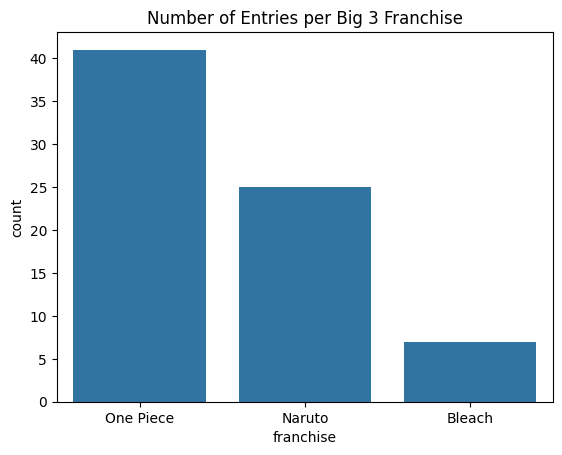

In [82]:
sns.countplot(
    x='franchise',
    data=big3
)

plt.title("Number of Entries per Big 3 Franchise")
plt.show()

One Piece dominates in amount of content produced. It has the largest number of entries in the dataset, reflecting its extensive collection of movies, specials, and side stories.

**Average Rating**

In [83]:
big3.groupby(
    'franchise'
)['rating'].mean().sort_values(
    ascending=False
)

franchise
One Piece    7.585610
Bleach       7.542857
Naruto       7.348800
Name: rating, dtype: float64

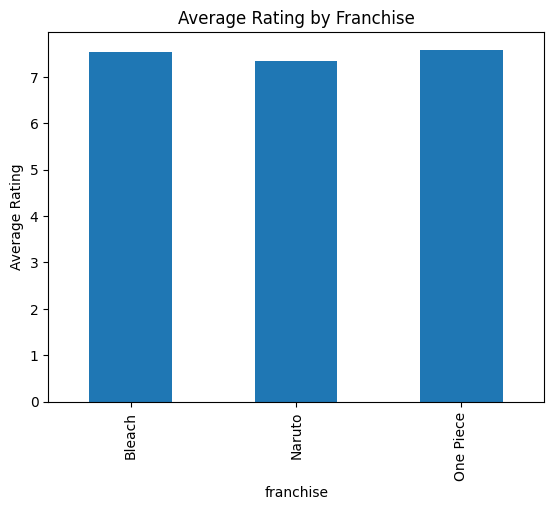

In [84]:
big3.groupby(
    'franchise'
)['rating'].mean().plot(
    kind='bar'
)

plt.ylabel("Average Rating")
plt.title("Average Rating by Franchise")
plt.show()

Among the Big 3 franchises, One Piece has the highest average rating, suggesting stronger overall audience reception within this dataset.

**Popularity**

In [85]:
big3.groupby(
    'franchise'
)['members'].sum().sort_values(
    ascending=False
)

franchise
Naruto       2611144
One Piece    1461982
Bleach       1278191
Name: members, dtype: int64

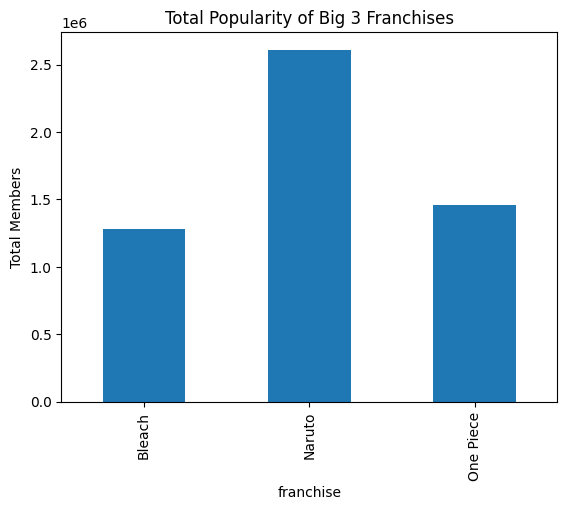

In [87]:
big3.groupby(
    'franchise'
)['members'].sum().plot(
    kind='bar'
)

plt.ylabel("Total Members")
plt.title("Total Popularity of Big 3 Franchises")
plt.show()

One Piece may have more entries, but total membership reveals that the Naruto franchise attracts the largest audience overall.

**Best rated installment**

In [88]:
for f in big3['franchise'].unique():

    print(f"\n{f}")

    display(
        big3[
            big3['franchise']==f
        ][['name','rating']]
        .sort_values(
            by='rating',
            ascending=False
        )
        .head(5)
    )


One Piece


,name,rating
74,One Piece,8.58
143,One Piece Film: Strong World,8.42
163,One Piece Film: Z,8.39
212,One Piece Film: Gold,8.32
231,One Piece: Episode of Merry - Mou Hitori no Na...,8.29



Naruto


,name,rating
486,Boruto: Naruto the Movie,8.03
615,Naruto: Shippuuden,7.94
719,The Last: Naruto the Movie,7.88
784,Naruto: Shippuuden Movie 6 - Road to Ninja,7.84
841,Naruto,7.81



Bleach


,name,rating
582,Bleach,7.95
946,Bleach Movie 4: Jigoku-hen,7.75
1131,Bleach Movie 3: Fade to Black - Kimi no Na wo ...,7.66
1274,Bleach Movie 2: The DiamondDust Rebellion - Mo...,7.60
1333,Bleach Movie 1: Memories of Nobody,7.58


One Piece dominates the Big 3 in terms of ratings, with the main series achieving a rating of 8.58 and multiple films scoring above 8.3.
The highest-rated Naruto-related title is Boruto: Naruto the Movie (8.03), followed closely by Naruto: Shippuden (7.94).
For Bleach, the main series itself remains the highest-rated entry with a score of 7.95.
Among all Big 3 entries, One Piece consistently occupies the highest positions, suggesting stronger overall audience reception in this dataset.

In [91]:
big3.groupby('franchise')['rating'].agg(
    ['count','mean','max']
).sort_values(
    by='mean',
    ascending=False
)

,count,mean,max
franchise,,,
One Piece,41,7.585610,8.58
Bleach,7,7.542857,7.95
Naruto,25,7.348800,8.03


One Piece not only contains the highest-rated individual entry but also achieves the highest average rating across all franchise installments, indicating consistently strong audience reception.

**Rating distribution**

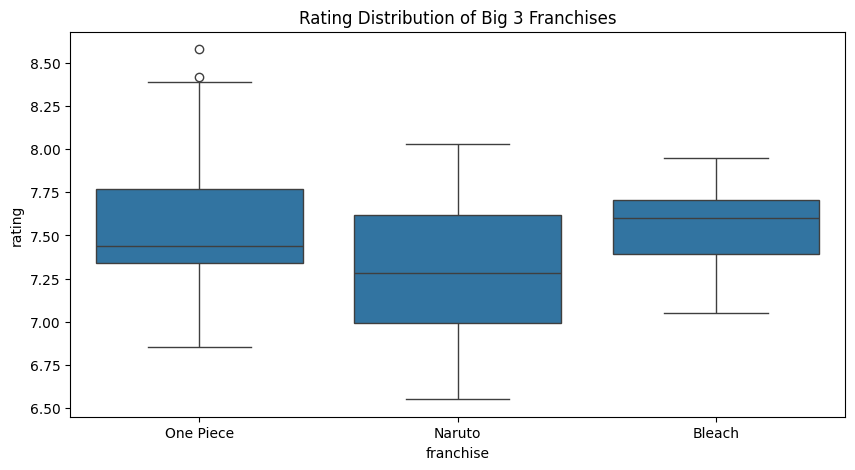

In [89]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='franchise',
    y='rating',
    data=big3
)

plt.title(
    "Rating Distribution of Big 3 Franchises"
)

plt.show()

The boxplot reveals not only average ratings but also consistency. A narrower spread suggests more consistent audience reception across franchise installments. Bleach has the highest average rating, considering this dataset

**Finding the most popular title from each franchise**

In [90]:
big3.loc[
    big3.groupby(
        'franchise'
    )['members'].idxmax(),
    ['franchise','name','members','rating']
]

,franchise,name,members,rating
582,Bleach,Bleach,624055,7.95
841,Naruto,Naruto,683297,7.81
74,One Piece,One Piece,504862,8.58


The original titles seem to be the most popular entries from each franchise.

**Final Conclusions**

**Key Findings**<br>
- Death Note and Attack on Titan are among the most popular anime by audience size.
- Rating-based rankings can be misleading without accounting for sample size.
- TV anime achieve the highest average ratings among anime formats.
- Thriller and Mystery genres tend to receive stronger audience ratings.
- Anime popularity is highly skewed, with a small number of titles attracting most viewers.
- Among the Big 3 franchises, One Piece achieves the highest average ratings while Naruto attracts the largest overall audience.
- The Big 3 continue to demonstrate strong audience engagement across multiple installments, movies, and specials.